# Explore here

### Paso 1 coleccion de datos

In [ ]:

import pandas as pd
#traemos los datos desde la url publica 
datos_importados_total = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv")
#mostramos el dataset
datos_importados_total



,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [ ]:
#lo transformamos a csv
datos_importados_total.to_csv("../data/raw/todos_datos.csv", index = False)

### Paso 2: exploracion y limpieza de datos

In [ ]:
# vemos las dimensiones 
datos_importados_total.shape
#mostramos el resumen del dataset
datos_importados_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

#### Elimnamos duplicados

In [ ]:
#estas colummnas las voy a usar como criterio para detectar filas duplicadas,es decir,si el valor en estas 5 
#columnas es igual se elimina,porque cuenta como duplicado y aqu eyo le he puesto estas columnas
cols_clave = ['name','host_id','latitude','longitude','room_type']

#se elimnan los registros con el .drop_duplicates y le metes como subset las columnas clave de antes
datos_importados_total = datos_importados_total.drop_duplicates(subset=cols_clave)

#### Eliminamos informacion irrelevante

In [ ]:
#elimino estas columnas porque me parecen irrelevantes a la hora de  hacer el eda,a la hora de calcular 
#algun dato o mostrar algun grafico no suirven para nada y algunas como last_review tiene nulos
datos_importados_total.drop(["id", "host_name", "last_review", "reviews_per_month"], axis = 1, inplace = True)
datos_importados_total.head()

,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Clean & quiet apt home by the park,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,Skylit Midtown Castle,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,THE VILLAGE OF HARLEM....NEW YORK !,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,Cozy Entire Floor of Brownstone,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,Entire Apt: Spacious Studio/Loft by central park,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


### Paso 3 Analisis de variables univariadas

#### Analisis de variables categoricas

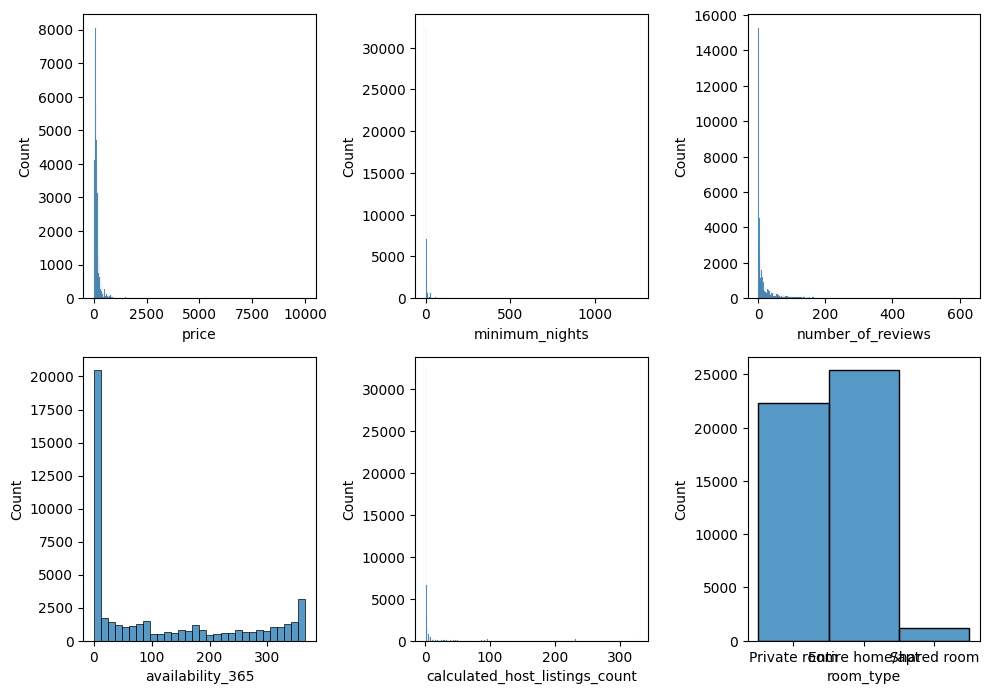

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns

#creo la figura con una cuadricula de 2 filas y 3 columnas(6 graficos en total) y figsize define el tamaño
#total de la figura
fig, axis = plt.subplots(2, 3, figsize = (10, 7))

# Crear un histograma múltiple,cada grafico lo asigno a una cuadricula con el axis[0,0] etc y en data meto
#los datos transformados ya y en x mi variable numerica que vamos a medir
sns.histplot(ax = axis[0, 0], data = datos_importados_total, x = "price")
sns.histplot(ax = axis[0, 1], data = datos_importados_total, x = "minimum_nights")
sns.histplot(ax = axis[0, 2], data = datos_importados_total, x = "number_of_reviews")
sns.histplot(ax = axis[1, 0], data = datos_importados_total, x = "availability_365")
sns.histplot(ax = axis[1, 1], data = datos_importados_total, x = "calculated_host_listings_count")
sns.histplot(ax = axis[1, 2], data = datos_importados_total, x = "room_type")

#ajusto el layout
plt.tight_layout()

#muestro el plot
plt.show()

#### Analisis de variables numericas

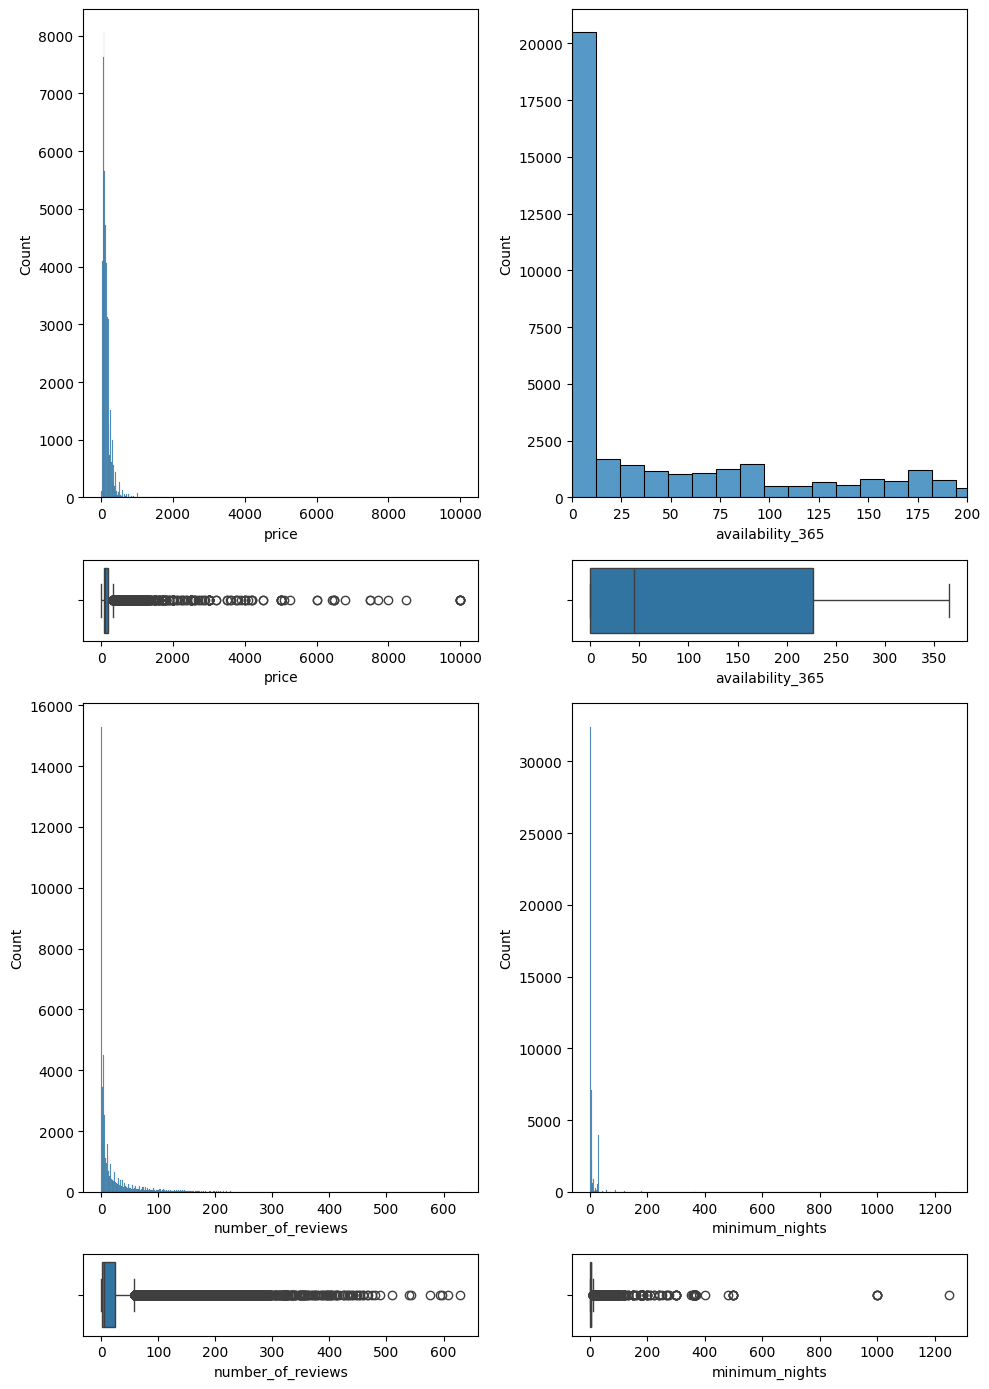

In [ ]:
#creo la figura con una cuadricula de 4 filas y 2 columnas(8 graficos en total) y figsize define el tamaño
#total de la figura,buneo y gridspec es un argumento para poner que las filas 0 y 2 son mmas altas y las
#1 y 3 son mas compactas,para ver mejor los histogramas basicamente
fig, axis = plt.subplots(4, 2, figsize = (10, 14), gridspec_kw = {"height_ratios": [6, 1, 6, 1]})

#columnas izquierda
#histograma para ver la distribucion de los precios
sns.histplot(ax = axis[0, 0], data = datos_importados_total, x = "price")
#boxplot para identificar outliers
sns.boxplot(ax = axis[1, 0], data = datos_importados_total, x = "price")

#columna derecha
#histograma para ver la disponibilidad anual limitado al rango 0-200 para ver mejor visualizacion
sns.histplot(ax = axis[0, 1], data = datos_importados_total, x = "availability_365").set_xlim(0, 200)
#boxplot para identificar outliers
sns.boxplot(ax = axis[1, 1], data = datos_importados_total, x = "availability_365")

#columnas izquierda
#histograma para analizar la distribucion del numero de reseñas
sns.histplot(ax = axis[2, 0], data = datos_importados_total, x = "number_of_reviews")
#boxplot para identificar outliers y para identificar alojamientos con un numero de reseñas inusualmente raro
sns.boxplot(ax = axis[3, 0], data = datos_importados_total, x = "number_of_reviews")

#columna derecha
#histograma para ver como se distribuyen  las noches minimas requeridas
sns.histplot(ax = axis[2,1], data = datos_importados_total, x = "minimum_nights")
#boxplot para identificar outliers en las noches minimas(estancias muy largas)
sns.boxplot(ax = axis[3, 1], data = datos_importados_total, x = "minimum_nights")

#ajusto el layout
plt.tight_layout()

#muestro el plot
plt.show()

### Paso 4 Analisis de variables multivariadas

####  Analisis numerico-numerico

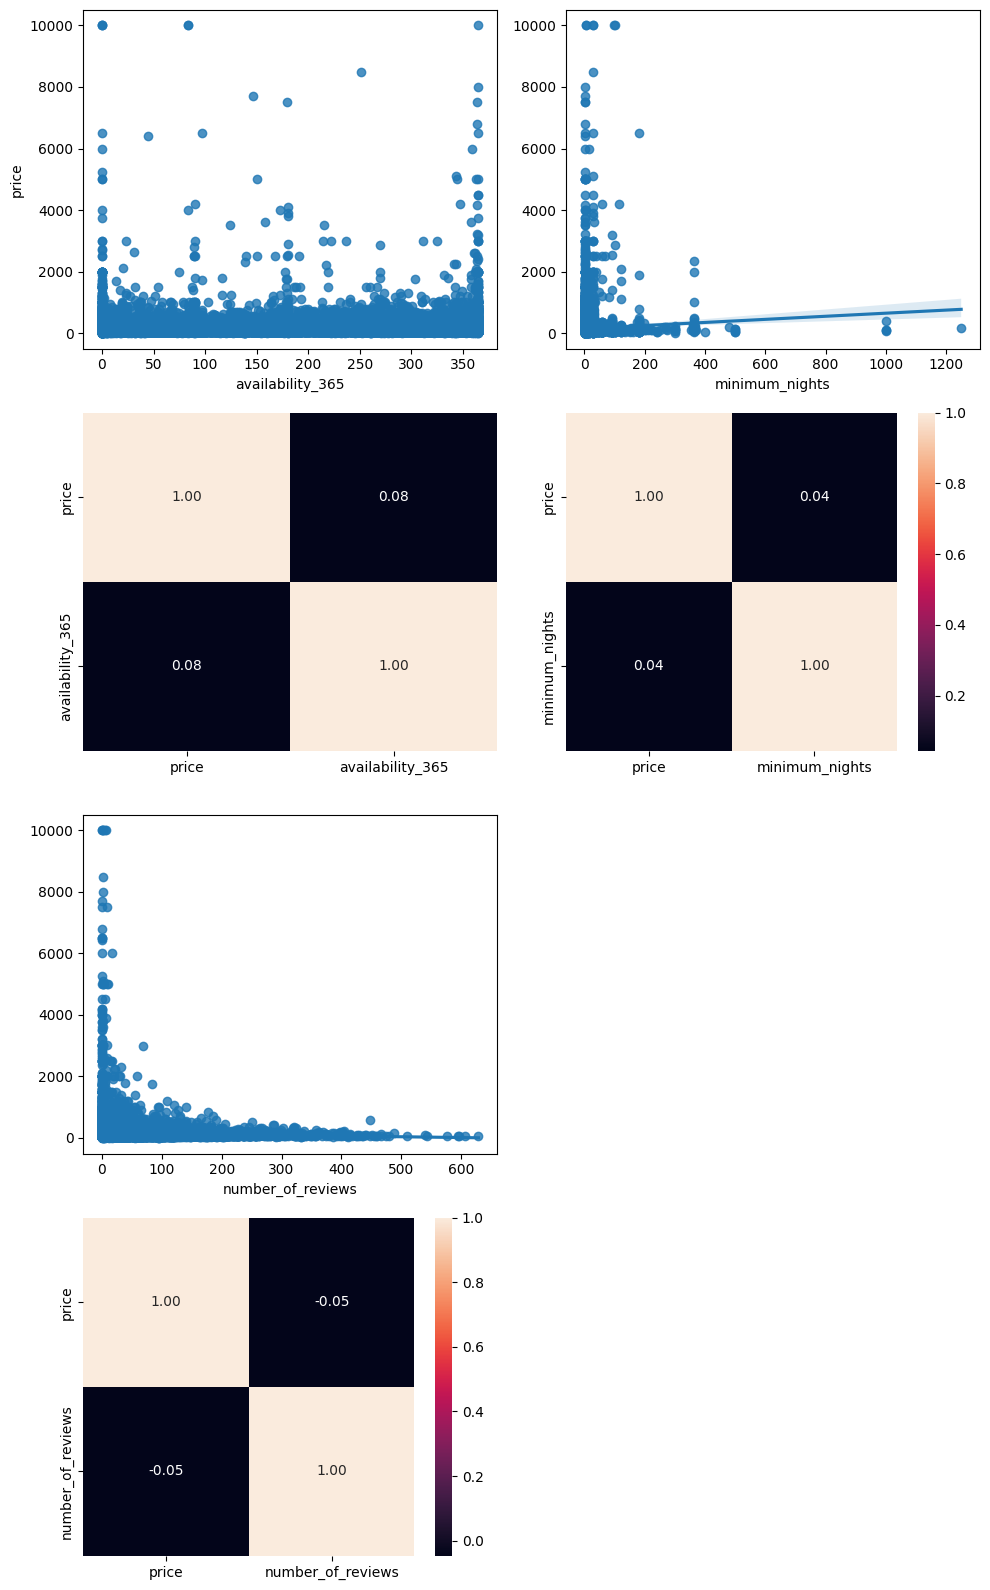

In [ ]:
#creo la figura con una cuadricula de 4 filas y 2 columnas(8 graficos en total) y figsize define el tamaño
#total de la figura
fig, axis = plt.subplots(4, 2, figsize = (10, 16))

#price vs availability
#hacemos el grafico de regrasion oara visualizar la tendencia lineal entre fisponibilidad y precio
sns.regplot(ax = axis[0, 0], data = datos_importados_total, x = "availability_365", y = "price")
#heatmap con el coeficiente de correlacion de ambas variables,anot muestra el valor numerico,fmt es para re
#dondear a 2 decimales y cbar es para ocultar la barra dde color
sns.heatmap(datos_importados_total[["price", "availability_365"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

#hacemos el grafico de regrasion oara visualizar la tendencia lineal entre nochers minimas y precio y el set y label none
#es comop y ahe puesto en el eje y en la primera el precio y ano lo repito porque en todos los graficos de 
#de regresion la y va a ser el precio
sns.regplot(ax = axis[0, 1], data = datos_importados_total, x = "minimum_nights", y = "price").set(ylabel = None)
#heatmap con el coeficiente de correlacion de ambas variables,anot muestra el valor numerico,fmt es para re
#dondear a 2 decimales y cbar es para ocultar la barra dde color
sns.heatmap(datos_importados_total[["price", "minimum_nights"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

#hacemos el grafico de regresion para visualizar la tendencia lineal entre numero de reseñas y precio y el set y label none
#es comop y he puesto en el eje y en la primera el precio y ano lo repito porque en todos los graficos de 
#de regresion la y va a ser el precio
sns.regplot(ax = axis[2, 0], data = datos_importados_total, x = "number_of_reviews", y = "price").set(ylabel = None)
#heatmap con el coeficiente de correlacion de ambas variables,anot muestra el valor numerico,fmt es para re
#dondear a 2 decimales y cbar es para ocultar la barra dde color
sns.heatmap(datos_importados_total[["price", "number_of_reviews"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0]).set(ylabel = None)

#elimino los ejes vacxios de la columnas derecha(filas 2 y 3)
fig.delaxes(axis[2, 1])
fig.delaxes(axis[3, 1])

#ajusto el layout
plt.tight_layout()

#muestro el plot
plt.show()

####  Analisis categorico-categorico

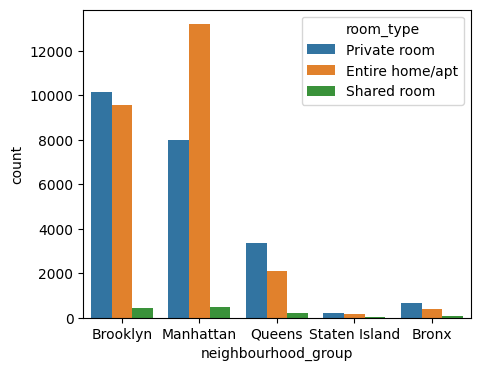

In [ ]:
#creo la figura con una cuadricula de 5 x 4 para el grafico
fig, axis = plt.subplots(figsize = (5, 4))

#grafico de barras que muestra la cantidad de alojamientos por barrio(neighbourhood_group) y con hue ponemos la leyenda
sns.countplot(data = datos_importados_total, x = "neighbourhood_group", hue = "room_type")

#mostramos la figura
plt.show()

#### Analisis numerico-categorico (completo)

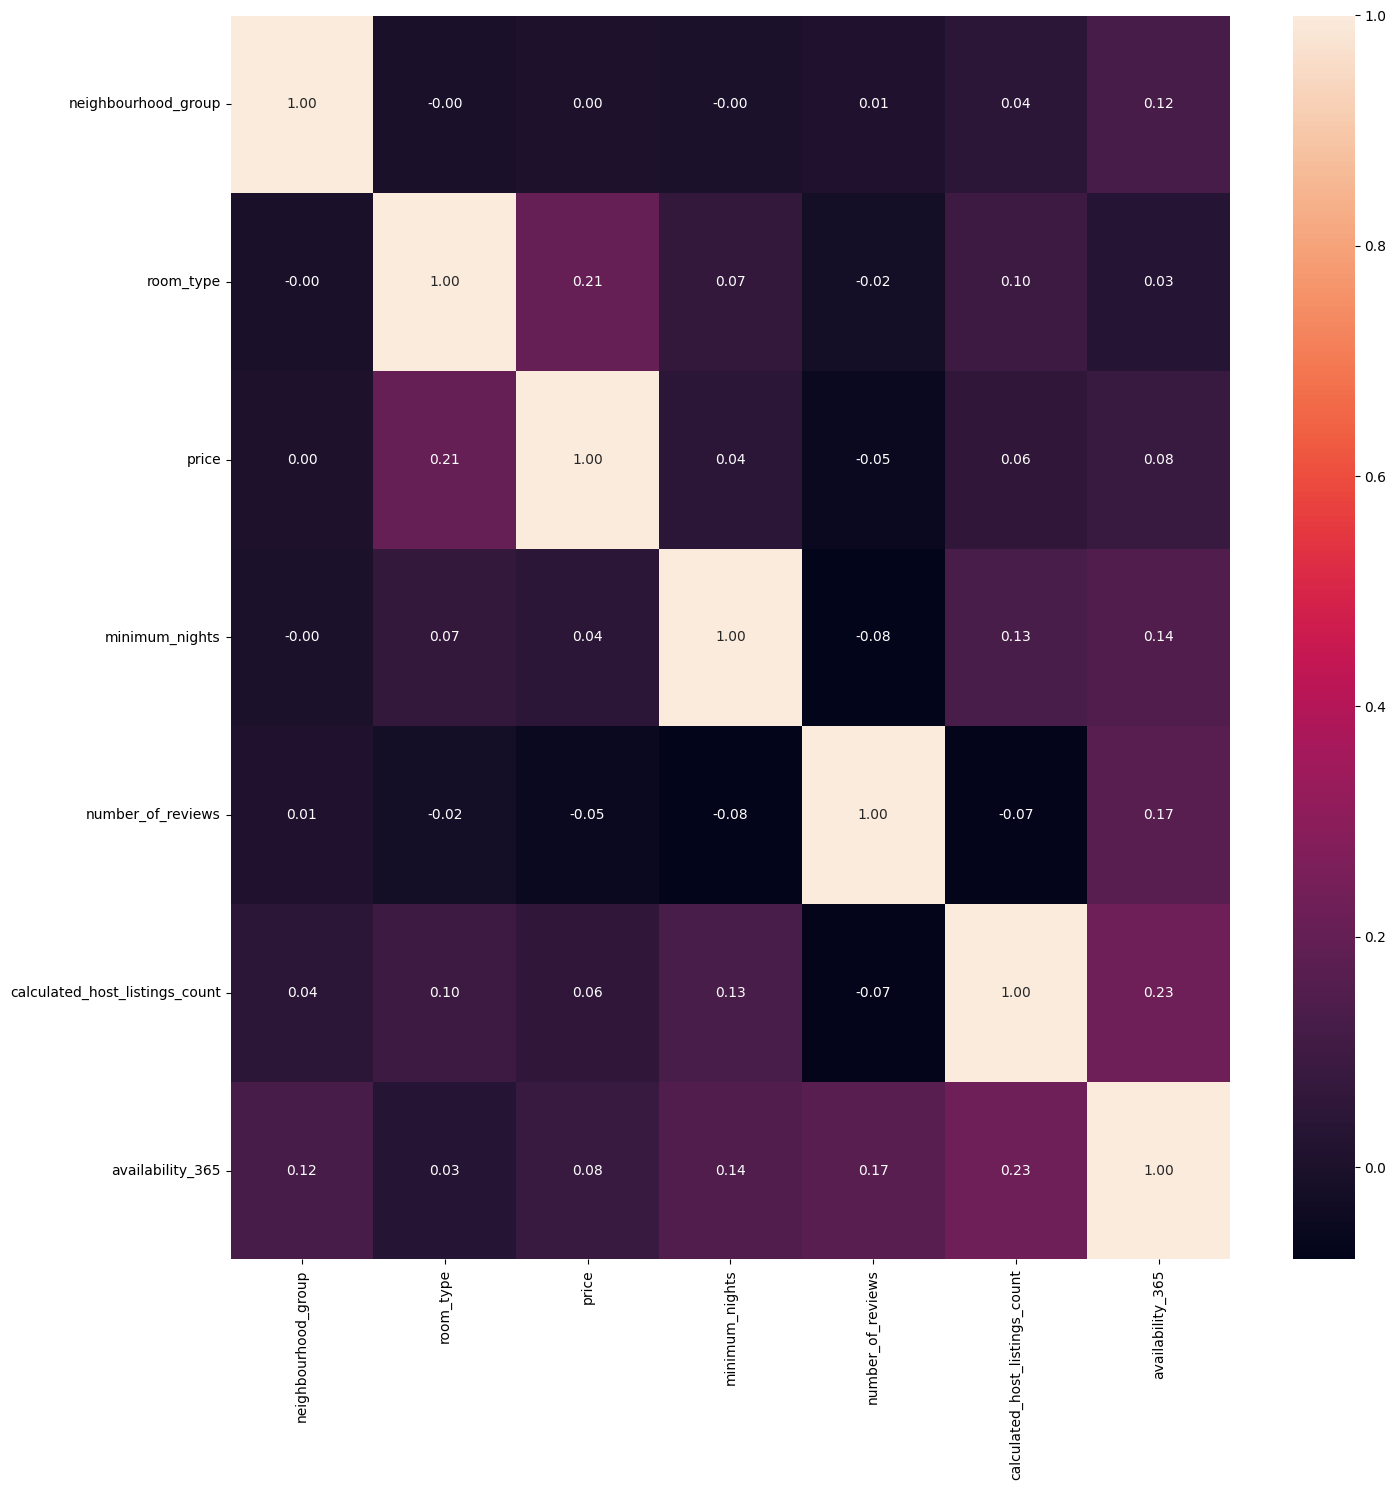

In [ ]:

#convierto las columnas categoricas a valores numericos,para luego hacer el hetamap,porque no se puede calcular
#una variable categorica con una numerica,no tiene sentido,entonces lo convertimos como a "numero",es decir,
#como si se pe puesiera 1,2,3,2,1,3,4 tipo asi,1 seria un valor,etc
datos_importados_total["room_type"] = pd.factorize(datos_importados_total["room_type"])[0]
datos_importados_total["neighbourhood_group"] = pd.factorize(datos_importados_total["neighbourhood_group"])[0]

#se crea la figura,que es amplia para que el heatmap se vea bien
fig, axes = plt.subplots(figsize=(15, 15))

#pintammos el heatmap con las variables relevantes del dataset,se seleccionan las variables a mano
#para excluir variables no numericas,annot muestra el numero de coeficiente de correlacion de cada celda y 
#fmt es oara redondearlo a 2 decimales
sns.heatmap(datos_importados_total[["neighbourhood_group", "room_type", "price", "minimum_nights",	
                        "number_of_reviews", "calculated_host_listings_count", "availability_365"]].corr(), annot = True, fmt = ".2f")

#ajusto el layout
plt.tight_layout()

#lo pinto
plt.show()

#### Analizazndo todos los datos a la vez

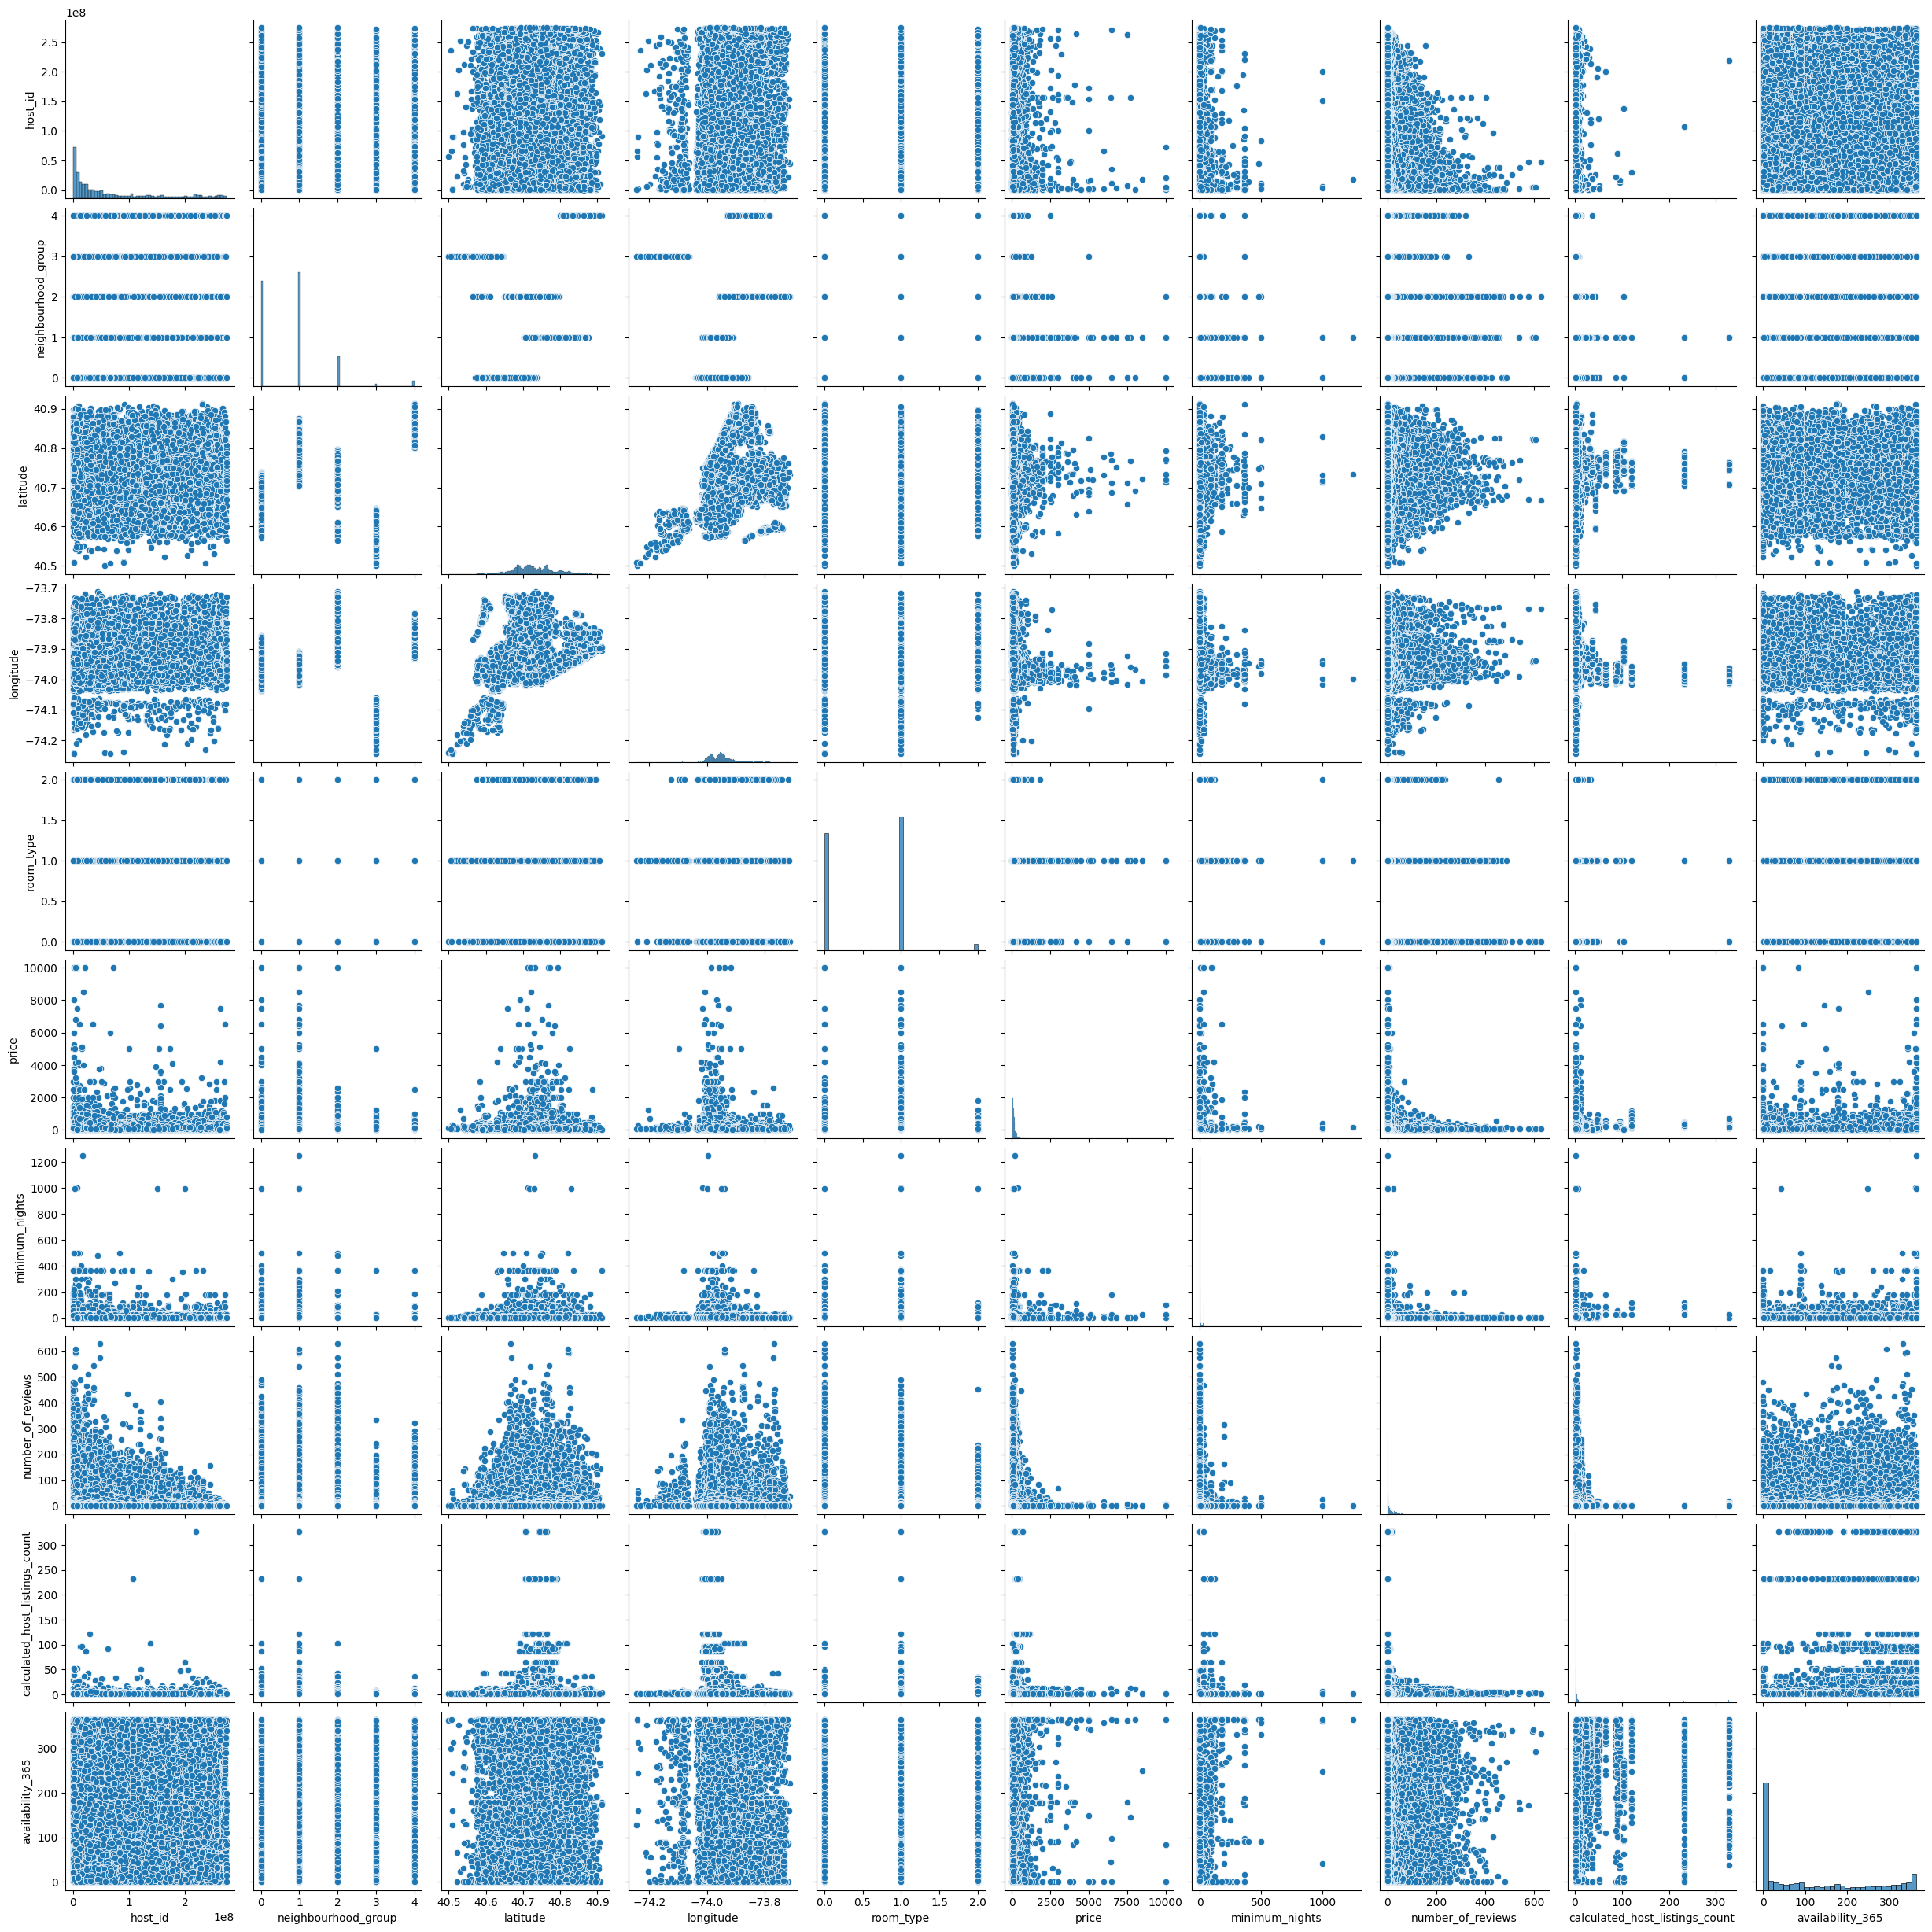

In [ ]:
#genero un pairplto que muestra la relacion entre todas las relaciones entre todas las variables numericas
#del dataframe,asi se ven facilmente patrones u outliers
sns.pairplot(data = datos_importados_total)

### Paso 5: Ingenieria de caracteristicas

In [ ]:
#genero un resumen estasdistico descriptivo de todas las variables numericas del dataframe
datos_importados_total.describe()

,host_id,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
count,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,6.762001e+07,0.786911,40.728949,-73.952170,0.567113,152.720687,7.029962,23.274466,7.143982,112.781327
std,7.861097e+07,0.844386,0.054530,0.046157,0.541249,240.154170,20.510550,44.550582,32.952519,131.622289
min,2.438000e+03,0.000000,40.499790,-74.244420,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,7.822033e+06,0.000000,40.690100,-73.983070,0.000000,69.000000,1.000000,1.000000,1.000000,0.000000
50%,3.079382e+07,1.000000,40.723070,-73.955680,1.000000,106.000000,3.000000,5.000000,1.000000,45.000000
75%,1.074344e+08,1.000000,40.763115,-73.936275,1.000000,175.000000,5.000000,24.000000,2.000000,227.000000
max,2.743213e+08,4.000000,40.913060,-73.712990,2.000000,10000.000000,1250.000000,629.000000,327.000000,365.000000


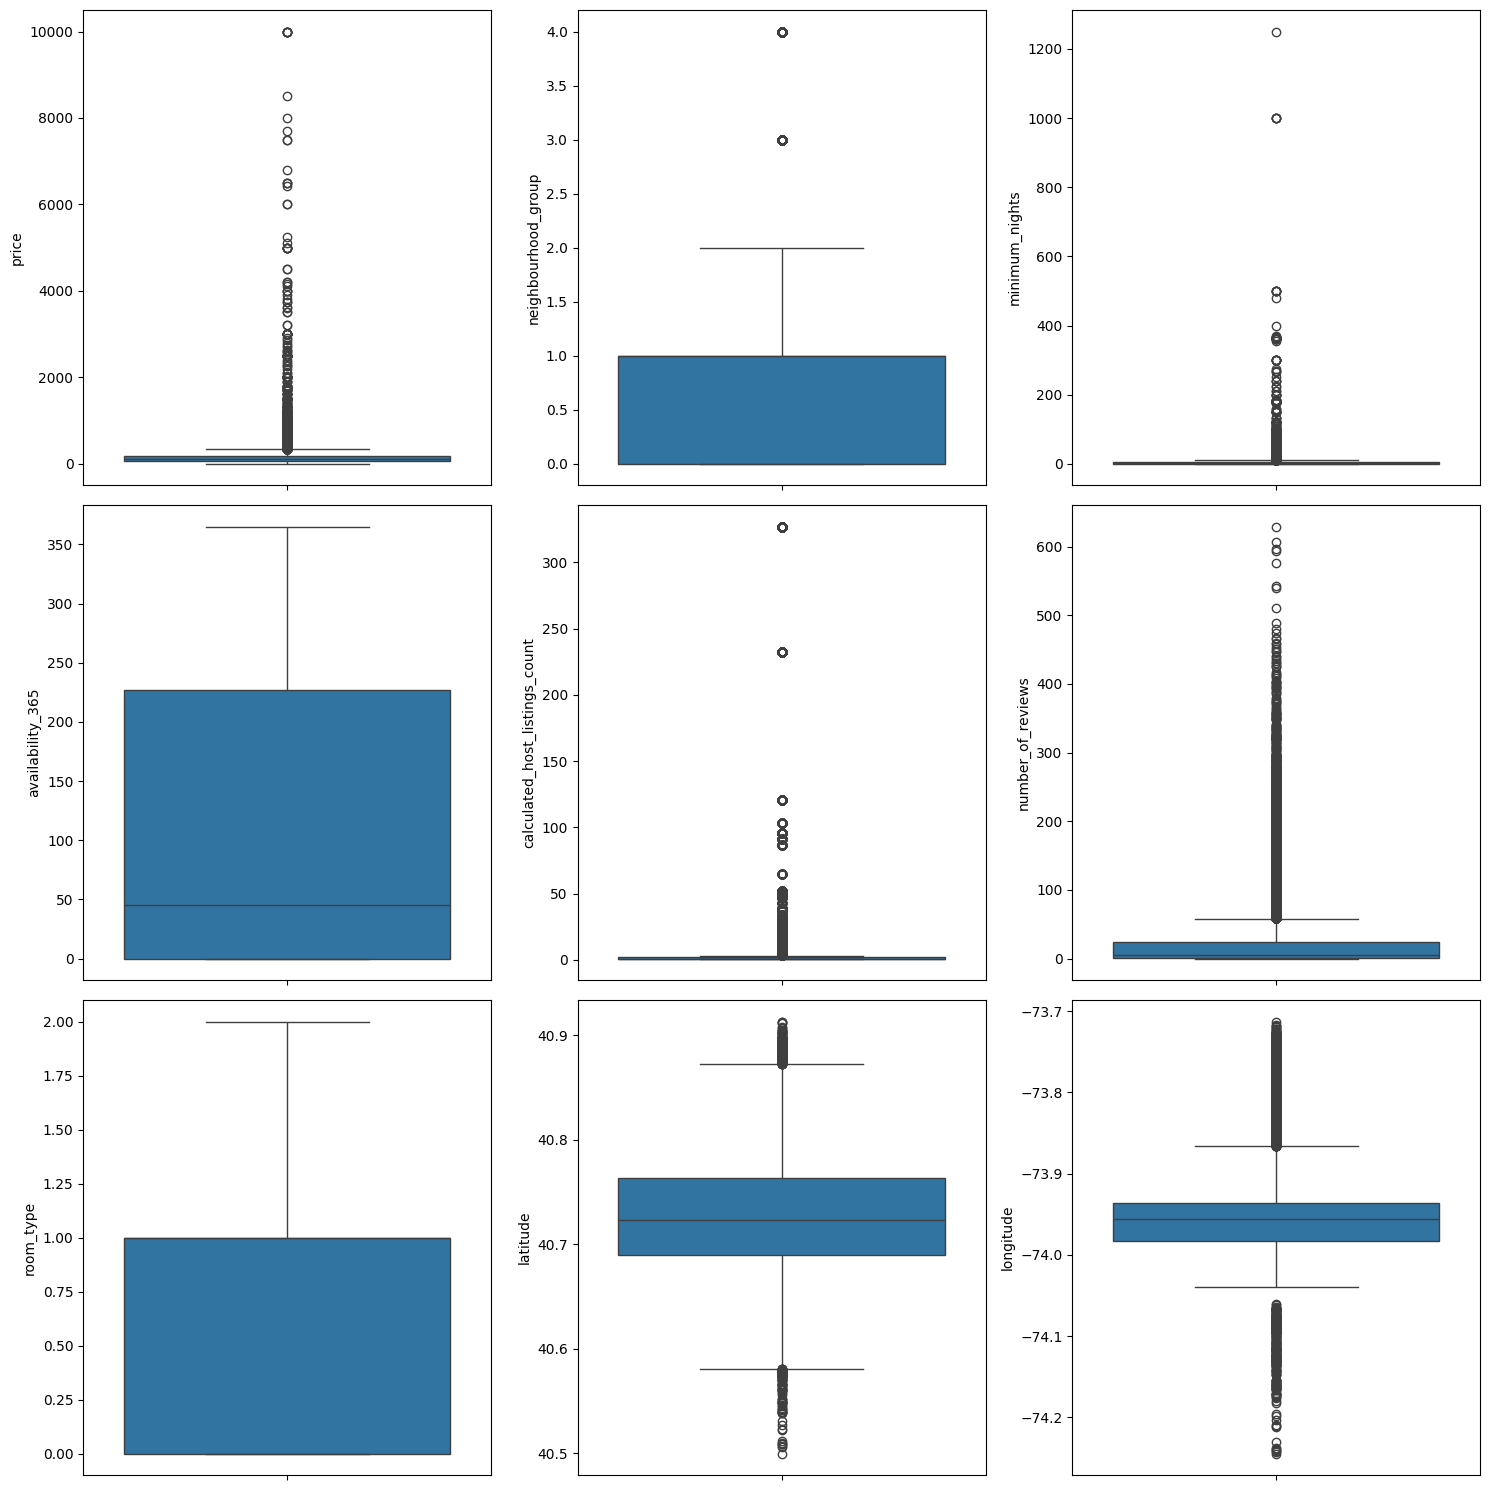

In [ ]:
#creo una figura con cuadricula de 3x3 (9 boxplots en total) para analizar la distreibucion y  outliers
#de todas las variables del dataframe
fig, axes = plt.subplots(3, 3, figsize = (15, 15))


sns.boxplot(ax = axes[0, 0], data = datos_importados_total, y = "price")
sns.boxplot(ax = axes[0, 1], data = datos_importados_total, y = "neighbourhood_group")
sns.boxplot(ax = axes[0, 2], data = datos_importados_total, y = "minimum_nights")
sns.boxplot(ax = axes[1, 0], data = datos_importados_total, y = "availability_365")
sns.boxplot(ax = axes[1, 1], data = datos_importados_total, y = "calculated_host_listings_count")
sns.boxplot(ax = axes[1, 2], data = datos_importados_total, y = "number_of_reviews")
sns.boxplot(ax = axes[2, 0], data = datos_importados_total, y = "room_type")
sns.boxplot(ax = axes[2, 1], data = datos_importados_total, y = "latitude")
sns.boxplot(ax = axes[2, 2], data = datos_importados_total, y = "longitude")

#ajusto el layout
plt.tight_layout()
#mmostramos la figura
plt.show()

##### Deteccion de outliers para price

In [ ]:
#sacamos solo el resumen estadistico descriptivo de minimas noches para trabajar con ellos
datos_noche = datos_importados_total["minimum_nights"].describe()
datos_noche

count    48895.000000
mean         7.029962
std         20.510550
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

In [ ]:
#calculo el rango intercuartilico de la variable minimas noches (50% de los datos) para leugo utilizarlo
iqr_noches = datos_noche["75%"] - datos_noche["25%"]
#calculo el limite superior,porque valores por encima de este valor se consideran outliers
upper_limit = datos_noche["75%"] + 1.5 * iqr_noches
#calculo el limite inferior,porque valores por debajo de este valor se consideran outliers
lower_limit = datos_noche["25%"] - 1.5 * iqr_noches

#lo imprimo
print(f"los limites superiores e inferiores de minimas noches son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango de interquartil de  {round(iqr_noches, 2)}")

los limites superiores e inferiores de minimas noches son 11.0 y -5.0, con un rango de interquartil de  4.0


In [ ]:
#filtro los registros eliminando outliers en minimunnn nights,solo cogiendo alojamientos que requieran 
#15 noches o menos y ponemos 15 porque el limite superior quye hemos calculado antes
total_data = datos_importados_total[datos_importados_total["minimum_nights"] <= 11]

#cuentoa alojamientos que tienen cada valor de noches minimas del 0 al 4 apra analizar la distribucion de los valores
#mas frecuentes y detectar posibles valores que no tienen sentido
count_0 = total_data[total_data["minimum_nights"] == 0].shape[0]
count_1 = total_data[total_data["minimum_nights"] == 1].shape[0]
count_2 = total_data[total_data["minimum_nights"] == 2].shape[0]
count_3 = total_data[total_data["minimum_nights"] == 3].shape[0]
count_4 = total_data[total_data["minimum_nights"] == 4].shape[0]

#se imprimen los contadores de cada numero de noches
print("contador de 0: ", count_0)
print("contador de 1: ", count_1)
print("contador de 2: ", count_2)
print("contador de 3: ", count_3)
print("contador de 4: ", count_4)

contador de 0:  0
contador de 1:  12720
contador de 2:  11696
contador de 3:  7999
contador de 4:  3303


#### Analisis de valores faltantes

In [ ]:
#mostramos las columanas que tienen nulos,y los ordenamos de manera desdecendente
datos_importados_total.isnull().sum().sort_values(ascending = False)

name                              16
host_id                            0
neighbourhood_group                0
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
calculated_host_listings_count     0
availability_365                   0
dtype: int64

#### Escalado de caracteristicas

In [35]:
from sklearn.preprocessing import MinMaxScaler

#columnas numericas que vamos a escalar
columnas_numericas = ["number_of_reviews", "minimum_nights", "calculated_host_listings_count", 
                 "availability_365", "neighbourhood_group", "room_type"]

#creamos el escalador
escalador = MinMaxScaler()

#plicar escalado
variables_escaladas = escalador.fit_transform(datos_importados_total[columnas_numericas])


#comvertimos a dataframe para mantener la estructura
datos_escalados = pd.DataFrame(variables_escaladas, index = datos_importados_total.index, columns = columnas_numericas)

#añadimos la variable objetivo (price)
datos_escalados["price"] = datos_importados_total["price"]

#lo mostramos
datos_escalados.head()

,number_of_reviews,minimum_nights,calculated_host_listings_count,availability_365,neighbourhood_group,room_type,price
0,0.014308,0.000000,0.015337,1.000000,0.00,0.0,149
1,0.071542,0.000000,0.003067,0.972603,0.25,0.5,225
2,0.000000,0.001601,0.000000,1.000000,0.25,0.0,150
3,0.429253,0.000000,0.000000,0.531507,0.00,0.5,89
4,0.014308,0.007206,0.000000,0.000000,0.25,0.5,80


### Paso 6: seleccion de caracteristicas

In [38]:
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split

#separamos variables y objetivo
X = datos_escalados.drop("price", axis = 1)
y = datos_escalados["price"]


#dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)


#seleccionamos las mejores variables
selector = SelectKBest(chi2, k = 5)

#entrenamos el selector
selector.fit(X_train, y_train)

#obtenemos las columnas seleccioandas
columnas_seleccionadas = selector.get_support()

#aplicamos la seleccion
X_train_sel = pd.DataFrame(selector.transform(X_train), columns = X_train.columns.values[columnas_seleccionadas])
X_test_sel = pd.DataFrame(selector.transform(X_test), columns = X_test.columns.values[columnas_seleccionadas])

#sacamos el resutlado
X_train_sel.head()

,number_of_reviews,calculated_host_listings_count,availability_365,neighbourhood_group,room_type
0,0.103339,0.000000,0.720548,0.50,0.5
1,0.038156,0.000000,0.032877,0.00,0.5
2,0.003180,0.000000,0.000000,0.25,0.0
3,0.006359,0.006135,0.000000,0.00,0.0
4,0.009539,0.000000,0.000000,0.25,1.0


####  Guardamos los datos limpios


In [ ]:
#se añade lña variable objetivo prioce a los conjuntos de prueba y entrenammiento
X_train_sel["price"] = list(y_train)
X_test_sel["price"] = list(y_test)
#se exportan los conjutnos de datos procesados a archivos CSV
X_train_sel.to_csv("../data/processed/train.csv", index = False)
X_test_sel.to_csv("../data/processed/test.csv", index = False)